# Week 3 — Occupation Audit
**Goal:** Before running any Nemotron experiments, manually audit 30 randomly sampled occupations
from the dataset and verify the sample is balanced across yes / no / maybe college-required categories.

**Instructions:**
1. Run Cell 1 — see the 30 occupations and histogram
2. Fill in `occupation_audit` in Cell 2 manually
3. Run Cell 3 — check balance and decide whether to proceed

> **Do not run Nemotron experiments until Cell 3 confirms the sample is balanced.**

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

sns.set_theme(style="whitegrid")

SAMPLE_PATH = "../data/personas_sample_500.csv"
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Imports OK")

Imports OK


## 2. Load Sample (No Cleaning)
Load the raw sample as-is — do not filter or fix any labels yet.

In [2]:
# Load raw sample — NO cleaning per advisor instruction
sample_raw = pd.read_csv(SAMPLE_PATH)

print(f"Sample size: {len(sample_raw)} rows")
print(f"Unique occupations in sample: {sample_raw['occupation'].nunique()}")
print(f"\nLabel balance:")
print(sample_raw["label_name"].value_counts())
print()
sample_raw.head(3)

Sample size: 500 rows
Unique occupations in sample: 222

Label balance:
label_name
not_college    276
college        224
Name: count, dtype: int64



,age,sex,marital_status,occupation,state,label,label_name,education_level
0,50,Male,married_present,police_officer,PA,1,college,bachelors
1,22,Male,never_married,waiter_or_waitress,KY,0,not_college,high_school
2,53,Female,married_present,community_or_social_service_specialist,CO,1,college,graduate


## 3. Sample 30 Random Occupations + Histogram

=== 30 randomly sampled occupations ===
   1. advertising or promotions manager
   2. animal trainer
   3. barber
   4. budget analyst
   5. chief executive
   6. chiropractor
   7. compliance officer
   8. construction equipment operator
   9. credit counselor or loan officer
  10. customer service representative
  11. dental or ophthalmic laboratory technician or medical appliance technician
  12. designer
  13. fast food or counter worker
  14. first line supervisor of housekeeping or janitorial worker
  15. industrial truck or tractor operator
  16. information security analyst
  17. inspector tester sorter sampler or weigher
  18. laundry or dry cleaning worker
  19. mechanical engineer
  20. office clerk general
  21. pharmacist
  22. physical therapist
  23. preschool or kindergarten teacher
  24. reservation or transportation ticket agent or travel clerk
  25. social or human service assistant
  26. surgical technologist
  27. teacher or instructor
  28. training or development

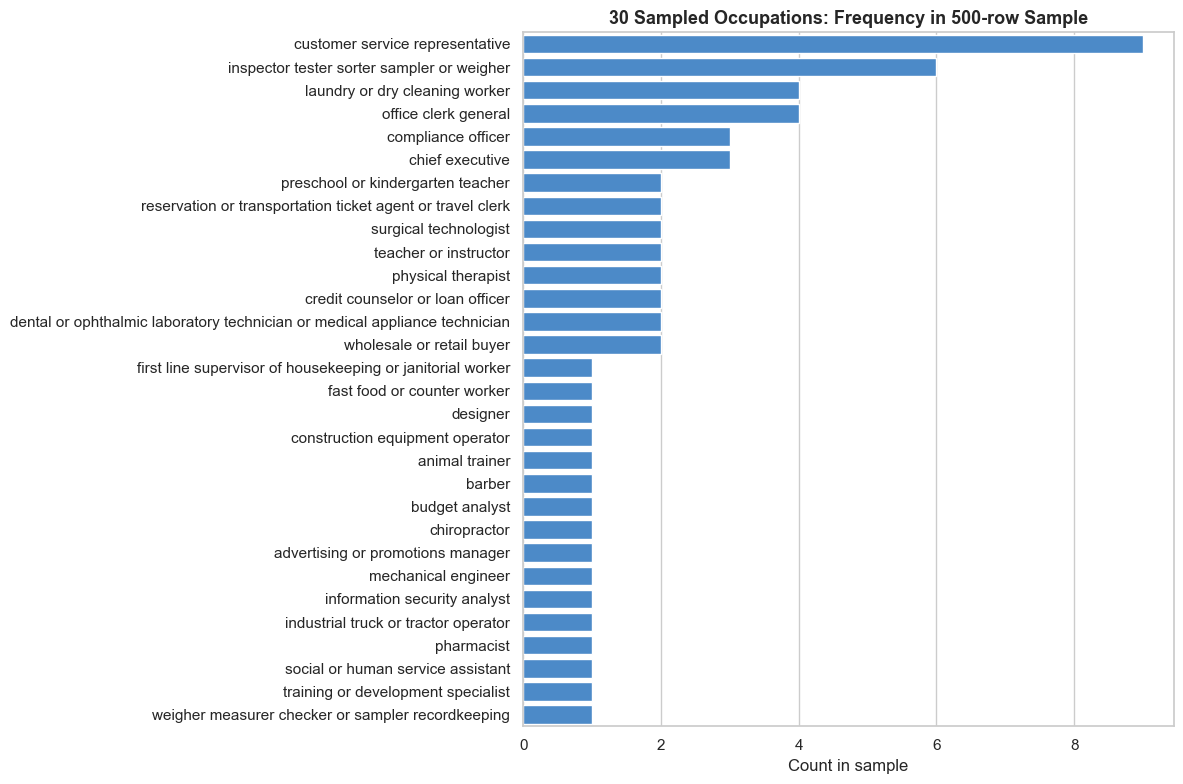

Saved: results/occupation_sample_audit.png


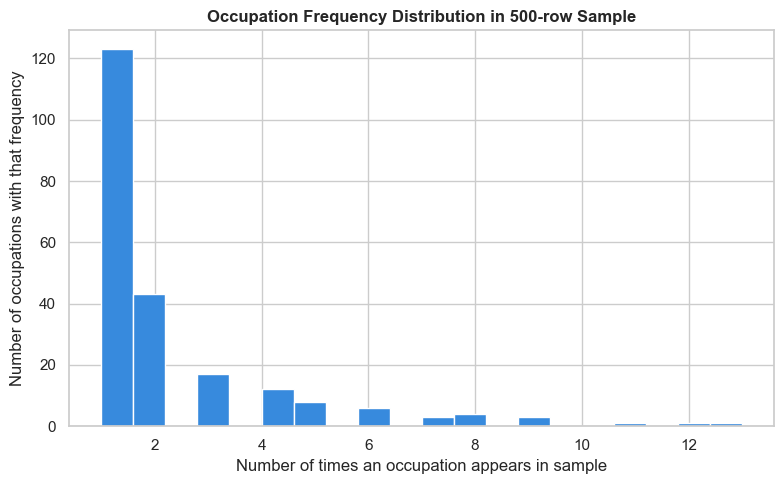

Saved: results/occupation_frequency_histogram.png


In [ ]:
# Sample 30 random unique occupations from the dataset
all_occupations = (
    sample_raw["occupation"]
    .str.replace("_", " ")
    .str.strip()
    .unique()
    .tolist()
)

random.seed(42)
sampled_30 = sorted(random.sample(all_occupations, 30))

print("=== 30 randomly sampled occupations ===")
for i, occ in enumerate(sampled_30, 1):
    print(f"  {i:2d}. {occ}")

# Count how many times each appears in the full sample
occ_counts = (
    sample_raw["occupation"]
    .str.replace("_", " ")
    .str.strip()
    .value_counts()
)

sampled_counts_df = pd.DataFrame(
    [(occ, occ_counts.get(occ, 0)) for occ in sampled_30],
    columns=["occupation", "count"]
).sort_values("count", ascending=False).reset_index(drop=True)

# Histogram
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=sampled_counts_df, x="count", y="occupation",
            color="#378ADD", ax=ax)
ax.set_title("30 Sampled Occupations: Frequency in 500-row Sample",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Count in sample")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/occupation_sample_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/occupation_sample_audit.png")


## 4. Manual Audit

Look at the 30 occupations printed above and fill in the dictionary below.

**Categories:**
- `"yes"` : this occupation clearly requires a college degree (e.g. surgeon, software engineer)
- `"no"` : this occupation clearly does not require a college degree (e.g. cashier, janitor)
- `"maybe"` : this occupation is ambiguous, could go either way (e.g. manager, supervisor)

> Fill in all 30 occupations, then run Cell 5 to check balance.

In [4]:
occupation_audit = {
    "advertising or promotions manager":                                          "yes",
    "animal trainer":                                                             "no",
    "barber":                                                                     "no",
    "budget analyst":                                                             "yes",
    "chief executive":                                                            "yes",
    "chiropractor":                                                               "yes",
    "compliance officer":                                                         "maybe",
    "construction equipment operator":                                            "no",
    "credit counselor or loan officer":                                           "maybe",
    "customer service representative":                                            "no",
    "dental or ophthalmic laboratory technician or medical appliance technician": "maybe",
    "designer":                                                                   "maybe",
    "fast food or counter worker":                                                "no",
    "first line supervisor of housekeeping or janitorial worker":                 "no",
    "industrial truck or tractor operator":                                       "no",
    "information security analyst":                                               "yes",
    "inspector tester sorter sampler or weigher":                                 "no",
    "laundry or dry cleaning worker":                                             "no",
    "mechanical engineer":                                                        "yes",
    "office clerk general":                                                       "no",
    "pharmacist":                                                                 "yes",
    "physical therapist":                                                         "yes",
    "preschool or kindergarten teacher":                                          "yes",
    "reservation or transportation ticket agent or travel clerk":                 "no",
    "social or human service assistant":                                          "maybe",
    "surgical technologist":                                                      "yes",
    "teacher or instructor":                                                      "yes",
    "training or development specialist":                                         "maybe",
    "weigher measurer checker or sampler recordkeeping":                          "no",
    "wholesale or retail buyer":                                                  "maybe",
}

print(f"Filled in: {len(occupation_audit)} / 30 occupations")
if len(occupation_audit) < 30:
    print("Fill in all 30 above, then run Cell 5.")
else:
    print("All 30 filled in — run Cell 5 to check balance.")

Filled in: 30 / 30 occupations
All 30 filled in — run Cell 5 to check balance.


## 5. Balance Check — Proceed or Not?

=== OCCUPATION AUDIT RESULTS ===

YES — 11 occupations:
  - advertising or promotions manager
  - budget analyst
  - chief executive
  - chiropractor
  - information security analyst
  - mechanical engineer
  - pharmacist
  - physical therapist
  - preschool or kindergarten teacher
  - surgical technologist
  - teacher or instructor

NO — 12 occupations:
  - animal trainer
  - barber
  - construction equipment operator
  - customer service representative
  - fast food or counter worker
  - first line supervisor of housekeeping or janitorial worker
  - industrial truck or tractor operator
  - inspector tester sorter sampler or weigher
  - laundry or dry cleaning worker
  - office clerk general
  - reservation or transportation ticket agent or travel clerk
  - weigher measurer checker or sampler recordkeeping

MAYBE — 7 occupations:
  - compliance officer
  - credit counselor or loan officer
  - dental or ophthalmic laboratory technician or medical appliance technician
  - designer
  - s

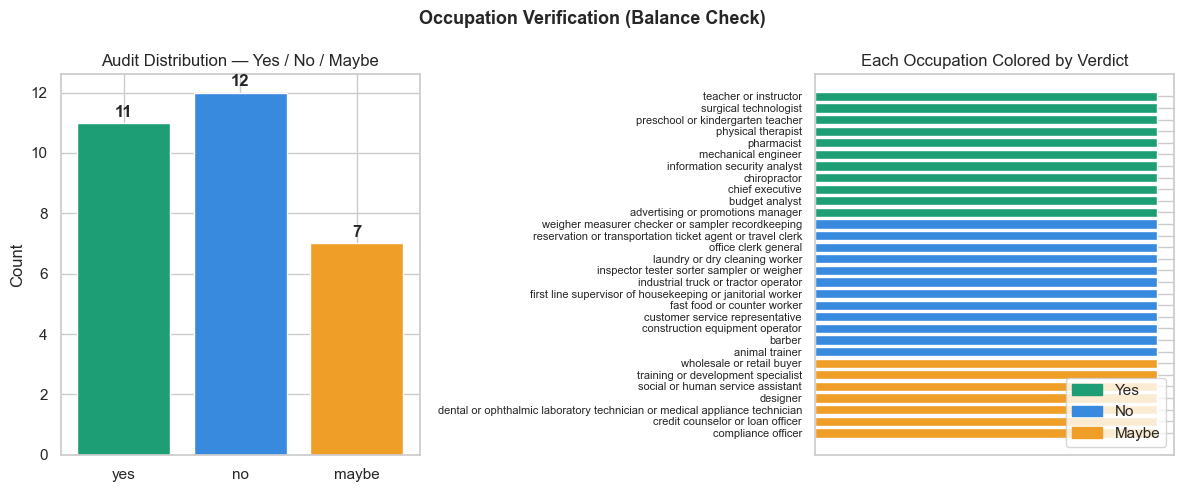

Saved: results/occupation_audit_balance.png

=== DECISION ===
✓ Sample is balanced — safe to proceed with Nemotron experiments.
  Next step: add the experiment cells and run Week 3.

Saved: results/occupation_audit_results.csv


In [5]:
if not occupation_audit:
    print("occupation_audit is empty — fill it in Cell 4 first.")
elif len(occupation_audit) < 30:
    print(f"Only {len(occupation_audit)}/30 filled in — complete Cell 4 first.")
else:
    audit_df = pd.DataFrame(
        [(occ, verdict) for occ, verdict in occupation_audit.items()],
        columns=["occupation", "verdict"]
    )

    # ── Results by category ───────────────────────────────────────────
    print("=== OCCUPATION AUDIT RESULTS ===")
    for verdict in ["yes", "no", "maybe"]:
        group = audit_df[audit_df["verdict"] == verdict]["occupation"].tolist()
        print(f"\n{verdict.upper()} — {len(group)} occupations:")
        for occ in group:
            print(f"  - {occ}")

    # ── Balance check ─────────────────────────────────────────────────
    counts    = audit_df["verdict"].value_counts()
    yes_pct   = counts.get("yes",   0) / 30 * 100
    no_pct    = counts.get("no",    0) / 30 * 100
    maybe_pct = counts.get("maybe", 0) / 30 * 100

    print(f"\n=== BALANCE CHECK ===")
    print(f"  Yes   (college):    {counts.get('yes',   0):2d} / 30  ({yes_pct:.0f}%)")
    print(f"  No    (not college):{counts.get('no',    0):2d} / 30  ({no_pct:.0f}%)")
    print(f"  Maybe (ambiguous):  {counts.get('maybe', 0):2d} / 30  ({maybe_pct:.0f}%)")

    # ── Visualization ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart of yes/no/maybe counts
    colors = ["#1D9E75", "#378ADD", "#EF9F27"]
    vc = audit_df["verdict"].value_counts().reindex(["yes", "no", "maybe"], fill_value=0)
    axes[0].bar(vc.index, vc.values, color=colors)
    axes[0].set_title("Audit Distribution — Yes / No / Maybe")
    axes[0].set_ylabel("Count")
    for i, (label, val) in enumerate(vc.items()):
        axes[0].text(i, val + 0.2, str(val), ha="center", fontsize=12, fontweight="bold")

    # Horizontal bar chart colored by verdict
    color_map  = {"yes": "#1D9E75", "no": "#378ADD", "maybe": "#EF9F27"}
    audit_plot = audit_df.sort_values("verdict")
    bar_colors = [color_map[v] for v in audit_plot["verdict"]]
    axes[1].barh(audit_plot["occupation"], [1]*30, color=bar_colors)
    axes[1].set_title("Each Occupation Colored by Verdict")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="y", labelsize=8)
    axes[1].set_xticks([])

    # Legend
    from matplotlib.patches import Patch
    legend = [Patch(color="#1D9E75", label="Yes"),
              Patch(color="#378ADD", label="No"),
              Patch(color="#EF9F27", label="Maybe")]
    axes[1].legend(handles=legend, loc="lower right")

    plt.suptitle("Occupation Verification (Balance Check)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/occupation_audit_balance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/occupation_audit_balance.png")

    # ── Decision ──────────────────────────────────────────────────────
    print("\n=== DECISION ===")
    if yes_pct >= 25 and no_pct >= 25 and maybe_pct >= 15:
        print("✓ Sample is balanced — safe to proceed with Nemotron experiments.")
        print("  Next step: add the experiment cells and run Week 3.")
    else:
        print("⚠ Sample may not be balanced enough.")
        if yes_pct < 25:
            print(f"  - Not enough YES occupations ({yes_pct:.0f}% — need at least 25%)")
        if no_pct < 25:
            print(f"  - Not enough NO occupations ({no_pct:.0f}% — need at least 25%)")
        if maybe_pct < 15:
            print(f"  - Not enough MAYBE occupations ({maybe_pct:.0f}% — need at least 15%)")
        print("  Discuss with your advisor before proceeding.")

    # Save audit results
    audit_df.to_csv(f"{RESULTS_DIR}/occupation_audit_results.csv", index=False)
    print("\nSaved: results/occupation_audit_results.csv")